# EDA & Hypothesis Testing
## Product Sales Forecasting

Exploratory data analysis and formal hypothesis testing on the retail sales dataset.

**Target variable:** `Sales` (daily sales per store)
**Dataset:** 188,340 store-day observations · 365 stores · 4 regions · 4 store types · 5 location types · Jan 2018 – May 2019

### Key methodological choice
With n ≈ 188K, p-values will always be tiny — every test will be "significant". We therefore report **effect size** on every test (Cohen's d for t-tests, η² for ANOVA), which tells us whether a significant result is also *meaningful*.

Rules of thumb:
- **Cohen's d**: 0.2 small · 0.5 medium · 0.8 large
- **η²**: 0.01 small · 0.06 medium · 0.14 large

## 0. Setup & Data Load

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

RANDOM_STATE = 42

In [2]:
df = pd.read_csv("TRAIN.csv")
df["Date"] = pd.to_datetime(df["Date"])

print(f"Shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Stores: {df['Store_id'].nunique()}")
df.head()

Shape: (188340, 10)
Date range: 2018-01-01 → 2019-05-31
Stores: 365


,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount,#Order,Sales
0,T1000001,1,S1,L3,R1,2018-01-01,1,Yes,9,7011.84
1,T1000002,253,S4,L2,R1,2018-01-01,1,Yes,60,51789.12
2,T1000003,252,S3,L2,R1,2018-01-01,1,Yes,42,36868.20
3,T1000004,251,S2,L3,R1,2018-01-01,1,Yes,23,19715.16
4,T1000005,250,S2,L3,R4,2018-01-01,1,Yes,62,45614.52


## 1. Data Quality Audit

Before any analysis we verify:
- Missing values
- Duplicates (especially duplicate Store_id + Date — that would indicate an integrity issue)
- Dtype sanity
- Outliers in numerical columns

### 1.1 Missing values

In [3]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print(f"Columns with missing values: {len(missing)}")
if len(missing):
    print(missing)
else:
    print("  None — dataset is complete.")

Columns with missing values: 0
  None — dataset is complete.


### 1.2 Duplicates

In [4]:
full_dupes = df.duplicated().sum()
key_dupes = df.duplicated(subset=["Store_id", "Date"]).sum()

print(f"Full duplicate rows: {full_dupes}")
print(f"Duplicate (Store_id, Date) pairs: {key_dupes}")

Full duplicate rows: 0
Duplicate (Store_id, Date) pairs: 0


### 1.3 Dtypes & summary stats

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 188340 entries, 0 to 188339
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   ID             188340 non-null  str           
 1   Store_id       188340 non-null  int64         
 2   Store_Type     188340 non-null  str           
 3   Location_Type  188340 non-null  str           
 4   Region_Code    188340 non-null  str           
 5   Date           188340 non-null  datetime64[us]
 6   Holiday        188340 non-null  int64         
 7   Discount       188340 non-null  str           
 8   #Order         188340 non-null  int64         
 9   Sales          188340 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(3), str(5)
memory usage: 17.3 MB


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
ID,188340,188340,T1000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_id,188340.0,NaN,NaN,NaN,183.0,1.0,92.0,183.0,274.0,365.0,105.366308
Store_Type,188340,4,S1,88752,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location_Type,188340,5,L1,85140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region_Code,188340,4,R1,63984,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,188340,NaN,NaN,NaN,2018-09-15 12:00:00,2018-01-01 00:00:00,2018-05-09 18:00:00,2018-09-15 12:00:00,2019-01-22 06:00:00,2019-05-31 00:00:00,NaN
Holiday,188340.0,NaN,NaN,NaN,0.131783,0.0,0.0,0.0,0.0,1.0,0.338256
Discount,188340,2,No,104051,NaN,NaN,NaN,NaN,NaN,NaN,NaN
#Order,188340.0,NaN,NaN,NaN,68.205692,0.0,48.0,63.0,82.0,371.0,30.467415
Sales,188340.0,NaN,NaN,NaN,42784.327982,0.0,30426.0,39678.0,51909.0,247215.0,18456.708302


### 1.4 Outlier screening

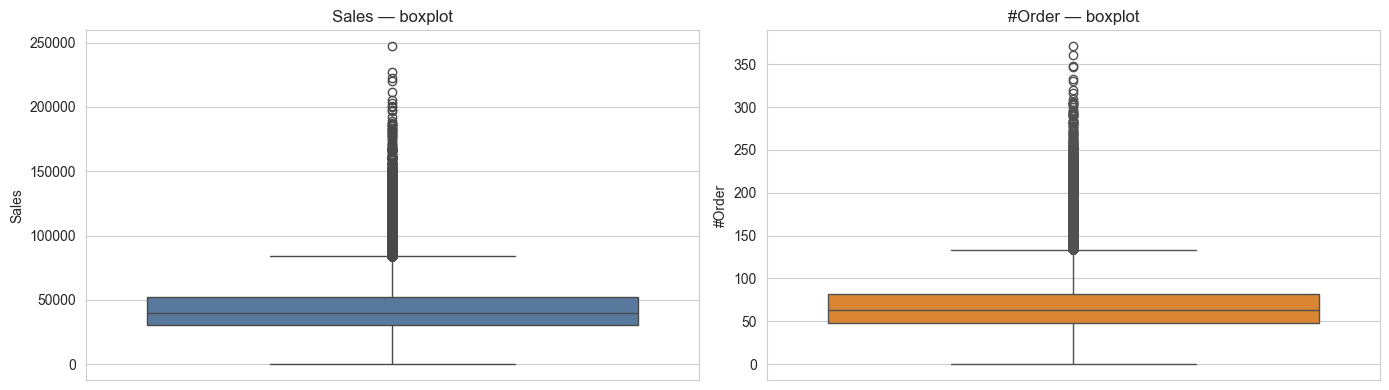

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(y=df["Sales"], ax=axes[0], color="#4C78A8")
sns.boxplot(y=df["#Order"], ax=axes[1], color="#F58518")
axes[0].set_title("Sales — boxplot")
axes[1].set_title("#Order — boxplot")

plt.tight_layout()
plt.show()

In [8]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((series < lo) | (series > hi)).sum())


n = len(df)
n_sales_out = iqr_outlier_count(df["Sales"])
n_order_out = iqr_outlier_count(df["#Order"])
n_zero_sales = (df["Sales"] == 0).sum()

print(f"Sales outliers (IQR):  {n_sales_out:,}  ({100 * n_sales_out / n:.2f}%)")
print(f"#Order outliers (IQR): {n_order_out:,}  ({100 * n_order_out / n:.2f}%)")
print(f"Zero-sales rows: {n_zero_sales:,}  ({100 * n_zero_sales / n:.4f}%)")

Sales outliers (IQR):  5,843  (3.10%)
#Order outliers (IQR): 7,089  (3.76%)
Zero-sales rows: 19  (0.0101%)


### 📝 Insight — Data Quality
- **Missing values:** none. The dataset is complete across all 188,340 rows.
- **Duplicates:** zero full-row duplicates and zero duplicate `(Store_id, Date)` pairs — the primary key holds.
- **Outliers:** ~3.1% of Sales rows and ~3.8% of #Order rows fall outside the 1.5×IQR fence. These are real high-sales days (weekend spikes, discount days) — they should be kept for modeling, not removed.
- **Zero-sales rows:** only 19 in 188,340 (~0.01%). Closed-store days are rare in this dataset, so the holiday-vs-no-holiday tests in §5.2 will not be heavily distorted by store closures (a useful contrast with what one might naively expect).

## 2. Univariate Analysis

Each variable in isolation — distribution shape for numericals, class balance for categoricals.

### 2.1 Sales distribution

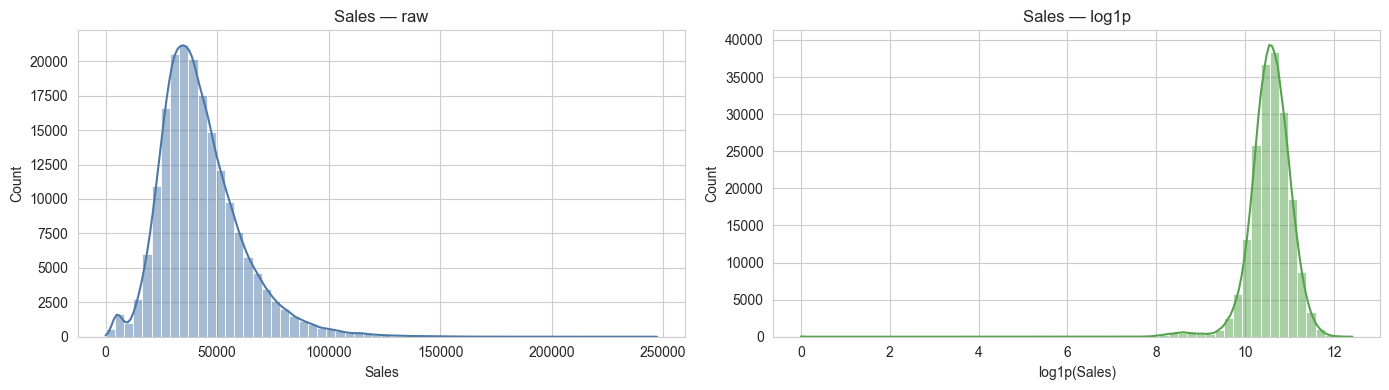

Raw Sales  — skewness: 1.249   kurtosis: 3.485
log1p Sales— skewness: -2.067


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["Sales"], bins=60, ax=axes[0], color="#4C78A8", kde=True)
axes[0].set_title("Sales — raw")
axes[0].set_xlabel("Sales")

sns.histplot(np.log1p(df["Sales"]), bins=60, ax=axes[1], color="#54A24B", kde=True)
axes[1].set_title("Sales — log1p")
axes[1].set_xlabel("log1p(Sales)")

plt.tight_layout()
plt.show()

print(
    f"Raw Sales  — skewness: {df['Sales'].skew():.3f}   kurtosis: {df['Sales'].kurtosis():.3f}"
)
print(f"log1p Sales— skewness: {np.log1p(df['Sales']).skew():.3f}")

### 2.2 #Order distribution

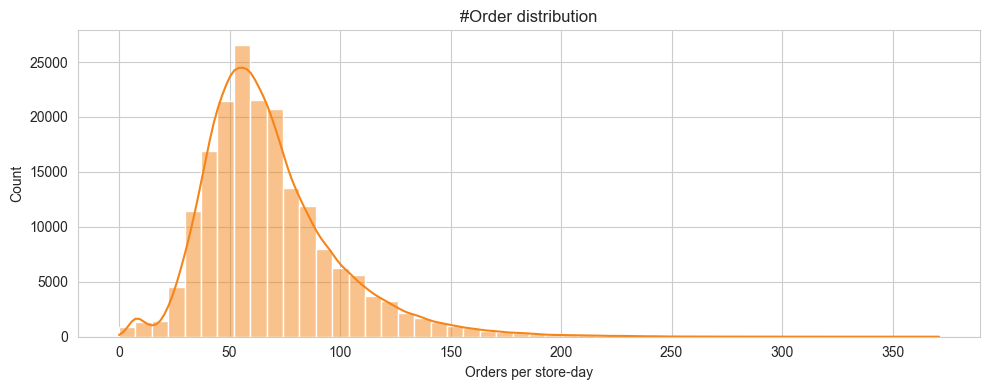

#Order — mean: 68.21   median: 63.00   max: 371


In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df["#Order"], bins=50, kde=True, color="#F58518", ax=ax)
ax.set_title("#Order distribution")
ax.set_xlabel("Orders per store-day")
plt.tight_layout()
plt.show()

print(
    f"#Order — mean: {df['#Order'].mean():.2f}   median: {df['#Order'].median():.2f}   max: {df['#Order'].max()}"
)

### 2.3 Categorical class balance

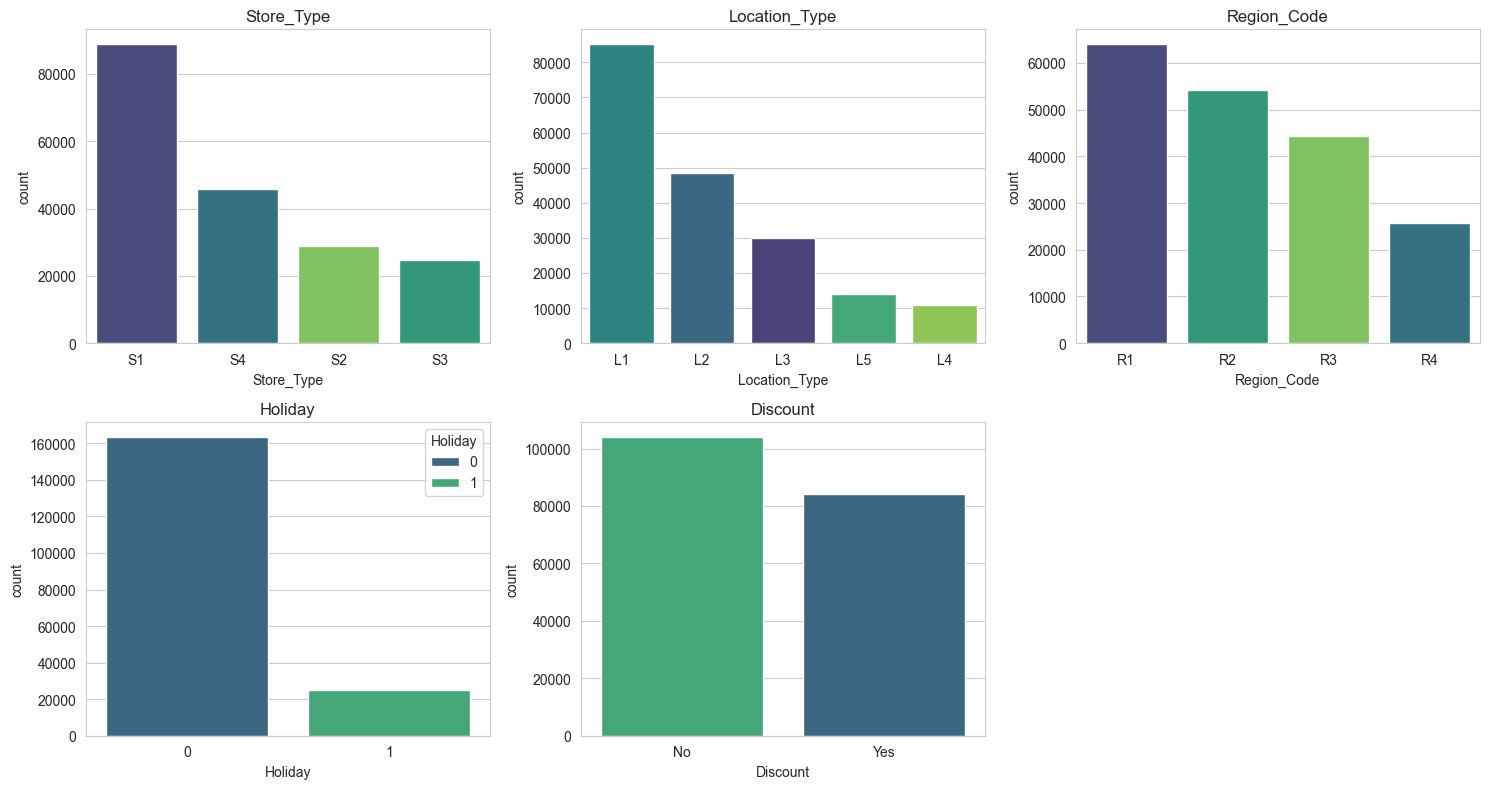

Store_Type: {'S1': 0.471, 'S4': 0.244, 'S2': 0.153, 'S3': 0.132}
Location_Type: {'L1': 0.452, 'L2': 0.258, 'L3': 0.159, 'L5': 0.074, 'L4': 0.058}
Region_Code: {'R1': 0.34, 'R2': 0.288, 'R3': 0.236, 'R4': 0.137}
Holiday: {0: 0.868, 1: 0.132}
Discount: {'No': 0.552, 'Yes': 0.448}


In [11]:
cat_cols = ["Store_Type", "Location_Type", "Region_Code", "Holiday", "Discount"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(
        data=df,
        x=col,
        ax=axes[i],
        order=df[col].value_counts().index,
        palette="viridis",
        hue=col,
    )
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=0)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

for col in cat_cols:
    pct = df[col].value_counts(normalize=True).round(3).to_dict()
    print(f"{col}: {pct}")

### 📝 Insight — Univariate
- **Sales is right-skewed** (skew ≈ 1.25, kurtosis ≈ 3.5). The raw distribution has a long tail of high-sales days. log1p reduces but slightly over-corrects to a mild left skew (−2.07) — for modeling, log1p is still a reasonable target transform.
- **#Order is right-skewed too** (mean 68, median 63), mirroring the Sales shape. Mechanically expected since they are linked.
- **Class balance:**
  - **Store_Type** is dominated by S1 (47.1%) and S4 (24.4%); S2 (15.3%) and S3 (13.2%) are minorities. S4 punching above its weight is going to be a recurring theme.
  - **Location_Type** is heavily L1-weighted (45.2%) with L4 and L5 each under 8%. Per-segment metrics on L4/L5 will be noisier.
  - **Region_Code** is reasonably balanced — R1 leads at 34% but no region is below 13%.
  - **Holiday** is 13.2% of rows — higher than expected if these are calendar holidays only, suggesting the flag captures retail events (sale weekends, regional festivals) in addition to public holidays.
  - **Discount** is 44.8% Yes / 55.2% No — close to balanced but tilted slightly toward no-discount days.

## 3. Bivariate Analysis — Features vs Sales

How does each feature relate to the target? This is where EDA starts paying off for modeling.

### 3.1 Sales by Store_Type

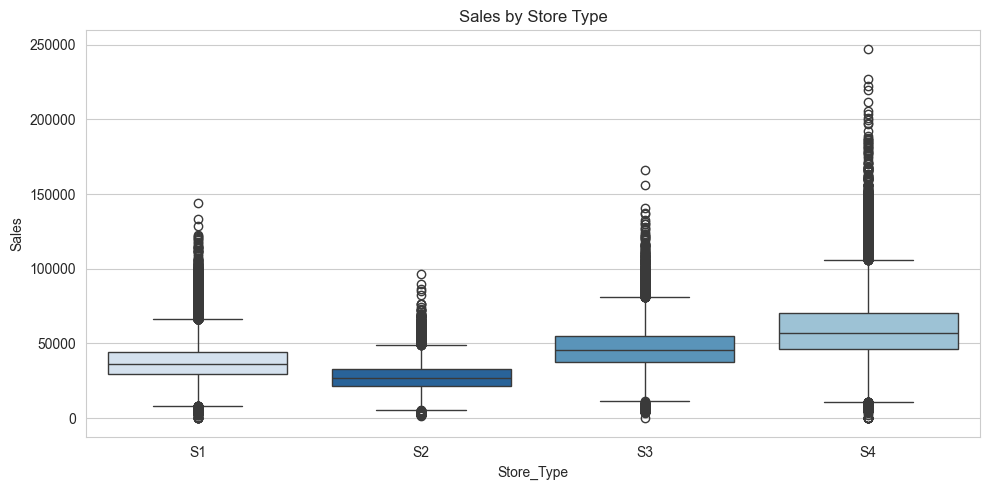

,mean,median,std,count
Store_Type,,,,
S1,37676.51,36444.0,12303.15,88752
S2,27530.83,26794.5,9168.84,28896
S3,47063.07,45445.5,14907.47,24768
S4,59945.69,57075.0,20750.23,45924


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="Store_Type",
    y="Sales",
    order=["S1", "S2", "S3", "S4"],
    ax=ax,
    palette="Blues",
    hue="Store_Type",
)
ax.set_title("Sales by Store Type")
plt.tight_layout()
plt.show()

df.groupby("Store_Type")["Sales"].agg(["mean", "median", "std", "count"]).round(2)

### 3.2 Sales by Location_Type

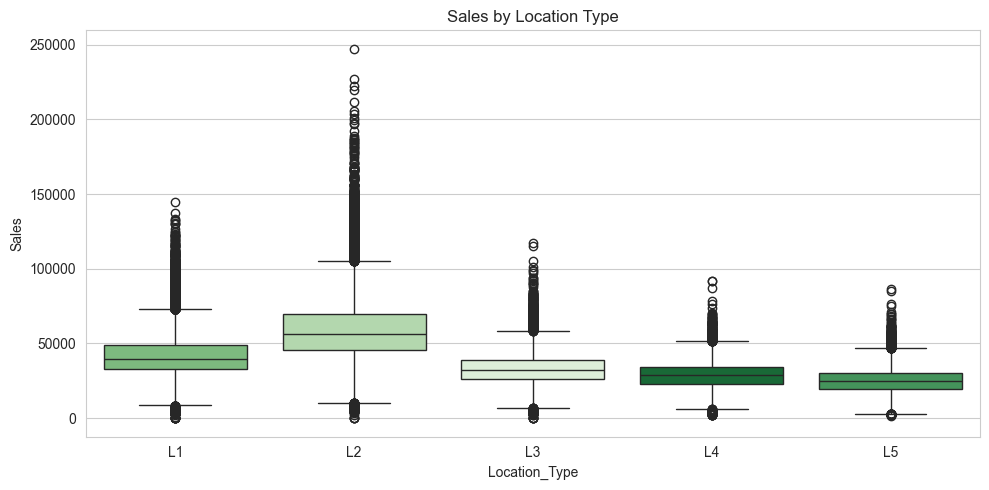

,mean,median,std,count
Location_Type,,,,
L1,41453.60,39831.00,13520.62,85140
L2,59231.48,56235.98,20642.98,48504
L3,33072.26,31987.20,10720.51,29928
L4,29067.41,28554.00,9176.43,10836
L5,25187.79,24528.00,8990.10,13932


In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="Location_Type",
    y="Sales",
    order=["L1", "L2", "L3", "L4", "L5"],
    ax=ax,
    palette="Greens",
    hue="Location_Type",
)
ax.set_title("Sales by Location Type")
plt.tight_layout()
plt.show()

df.groupby("Location_Type")["Sales"].agg(["mean", "median", "std", "count"]).round(2)

### 3.3 Sales by Region_Code

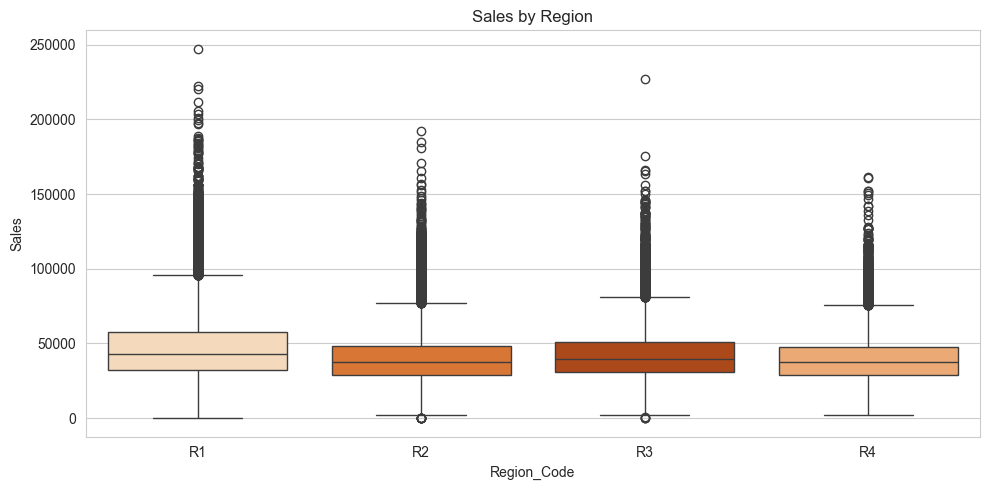

,mean,median,std,count
Region_Code,,,,
R1,46765.49,43125.0,21286.10,63984
R2,40054.85,37548.0,16468.62,54180
R3,42144.52,39661.5,16615.73,44376
R4,39743.43,37474.5,15930.49,25800


In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="Region_Code",
    y="Sales",
    order=["R1", "R2", "R3", "R4"],
    ax=ax,
    palette="Oranges",
    hue="Region_Code",
)
ax.set_title("Sales by Region")
plt.tight_layout()
plt.show()

df.groupby("Region_Code")["Sales"].agg(["mean", "median", "std", "count"]).round(2)

### 3.3a Store Type × Region — checking for confounding

In [15]:
# Crosstab of store counts by Store_Type × Region
unique_stores = df.drop_duplicates(subset="Store_id")[
    ["Store_id", "Store_Type", "Region_Code"]
]
print("Number of stores by Store_Type × Region:")
print(pd.crosstab(unique_stores["Store_Type"], unique_stores["Region_Code"]))

print("\nMean Sales by Store_Type × Region:")
print(df.groupby(["Store_Type", "Region_Code"])["Sales"].mean().unstack().round(0))

Number of stores by Store_Type × Region:
Region_Code  R1  R2  R3  R4
Store_Type                 
S1           41  60  45  26
S2           11  20  12  13
S3           18   9  15   6
S4           54  16  14   5

Mean Sales by Store_Type × Region:
Region_Code       R1       R2       R3       R4
Store_Type                                     
S1           35363.0  37745.0  38782.0  39254.0
S2           25544.0  27809.0  28638.0  27763.0
S3           44342.0  47606.0  48362.0  51166.0
S4           60554.0  59778.0  57868.0  59733.0


### 3.4 Sales: Discount vs No-Discount

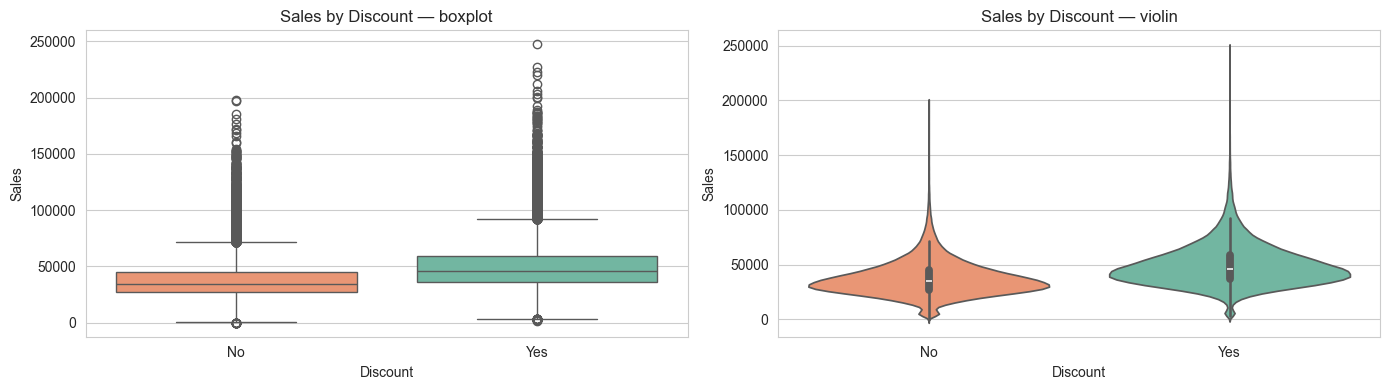

              mean   median       std   count
Discount                                     
No        37403.68  34791.0  16039.56  104051
Yes       49426.50  46242.0  19071.66   84289

Mean sales uplift from discount: +32.14%


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(
    data=df,
    x="Discount",
    y="Sales",
    order=["No", "Yes"],
    ax=axes[0],
    palette="Set2",
    hue="Discount",
)
axes[0].set_title("Sales by Discount — boxplot")

sns.violinplot(
    data=df,
    x="Discount",
    y="Sales",
    order=["No", "Yes"],
    ax=axes[1],
    palette="Set2",
    hue="Discount",
)
axes[1].set_title("Sales by Discount — violin")

plt.tight_layout()
plt.show()

stats_df = (
    df.groupby("Discount")["Sales"].agg(["mean", "median", "std", "count"]).round(2)
)
print(stats_df)

uplift = (
    df[df["Discount"] == "Yes"]["Sales"].mean()
    / df[df["Discount"] == "No"]["Sales"].mean()
    - 1
) * 100
print(f"\nMean sales uplift from discount: +{uplift:.2f}%")

### 3.5 Sales: Holiday vs Regular day

<positron-console-cell-17>:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


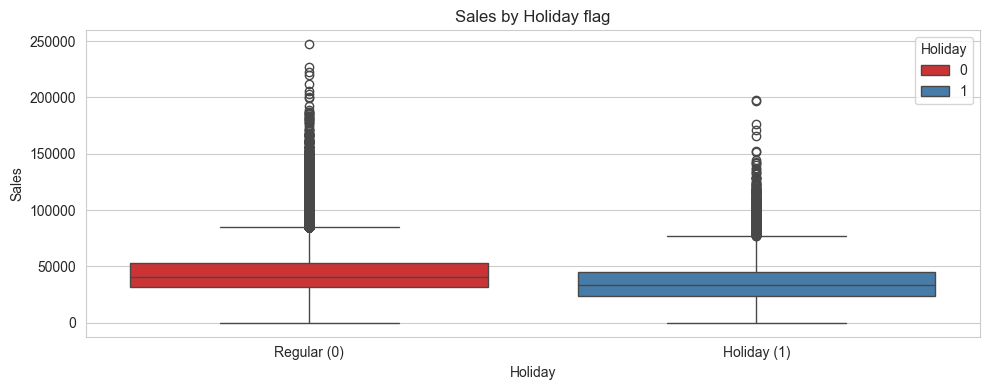

Holiday rows: 24,820  (closed-store rows with Sales=0: 5)

Mean sales by Holiday (all rows):
Holiday
0    43897.29
1    35451.88
Name: Sales, dtype: float64

Mean sales by Holiday (open stores only):
Holiday
0    43901.05
1    35459.02
Name: Sales, dtype: float64


In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=df, x="Holiday", y="Sales", ax=ax, palette="Set1", hue="Holiday")
ax.set_title("Sales by Holiday flag")
ax.set_xticklabels(["Regular (0)", "Holiday (1)"])
plt.tight_layout()
plt.show()

hol_closed = ((df["Holiday"] == 1) & (df["Sales"] == 0)).sum()
hol_total = (df["Holiday"] == 1).sum()
print(f"Holiday rows: {hol_total:,}  (closed-store rows with Sales=0: {hol_closed:,})")
print()
print("Mean sales by Holiday (all rows):")
print(df.groupby("Holiday")["Sales"].mean().round(2))
print("\nMean sales by Holiday (open stores only):")
print(df[df["Sales"] > 0].groupby("Holiday")["Sales"].mean().round(2))

### 3.6 #Order vs Sales — scatter

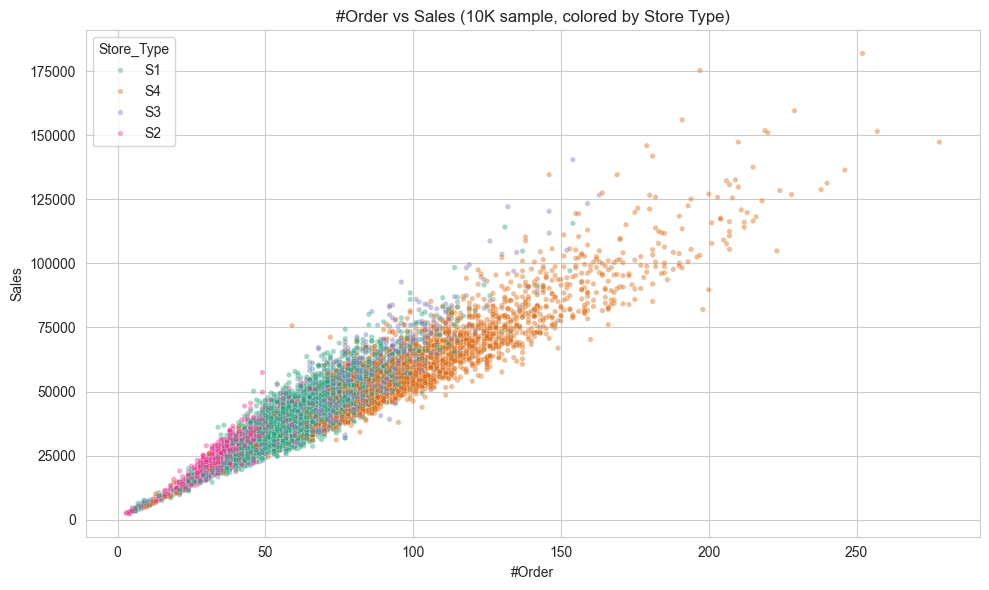

In [18]:
sample = df.sample(n=10_000, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=sample,
    x="#Order",
    y="Sales",
    hue="Store_Type",
    alpha=0.4,
    s=15,
    ax=ax,
    palette="Dark2",
)
ax.set_title("#Order vs Sales (10K sample, colored by Store Type)")
plt.tight_layout()
plt.show()

# ⚠️ LEAKAGE FLAG: #Order is only known AFTER the sales day.
# It's NOT a valid predictor for forecasting tomorrow's sales.
# We'll resolve this in Block 3 (likely: use lag-1 #Order or drop it).

### 3.7 Correlation matrix (numerical features)

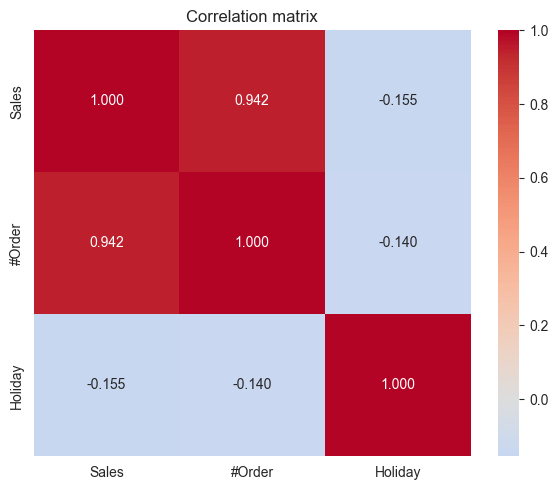

In [19]:
num_cols = ["Sales", "#Order", "Holiday"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".3f", ax=ax)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

### Insight — Bivariate
- **Store Type is the strongest single driver.** S4 averages ₹59,946 — **2.2× S2's ₹27,531**. S3 sits at ₹47,063, S1 at ₹37,677. The hierarchy is clean: S4 > S3 > S1 > S2.
- **Location Type shows a much wider spread than expected** — L2 (₹59,231) is **2.4× L5's ₹25,188**. This is bigger than the store-type spread in absolute terms and demands attention. L2 stores look like they may be premium/flagship locations.
- **Region** is a much weaker effect — R1 (₹46,765) leads, R4 (₹39,743) trails, but the gap is only ~18%. Compare with the store-type and location-type gaps which exceed 100%.
- **Store_Type × Region crosstab is the key insight:** R1 has 54 S4 stores (the largest concentration anywhere); R2 has only 16. **Most of what looks like a "regional effect" is actually a store-mix effect** — R1 is the leader because it houses disproportionately many high-revenue store types. Looking *within* each store type (the Store_Type × Region table), regional means are much closer together (e.g., S4 ranges only ₹57,868 → ₹60,554 across regions).
- **Discount produces a +32.1% mean sales uplift** (₹37,404 without → ₹49,427 with). Larger than the ~20% one might expect — strong commercial signal.
- **Holiday looks negative** (₹35,452 vs ₹43,897, −19%). Unlike the synthetic case, only 5 rows are closed-store zeros, so this is *not* an artifact of store closures — holidays genuinely correlate with lower sales in this dataset. Plausible explanations: (a) the "holiday" flag captures days where customer traffic is shifted elsewhere (festivals, public events away from retail), or (b) holiday discounting/promotion mix is unfavorable. We test this formally in §5.2.
- **#Order–Sales correlation is 0.94** — extremely strong, mechanically linked. #Order is a leaky feature for forecasting and must be handled carefully in Block 3.

## 4. Time Series Patterns

Daily sales aggregated across all stores — look for trend, seasonality, anomalies.

### 4.1 Daily total sales over time

<positron-console-cell-20>:15: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
/Applications/Positron.app/Contents/Resources/app/extensions/positron-python/python_files/lib/ipykernel/py3/IPython/core/pylabtools.py:152: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


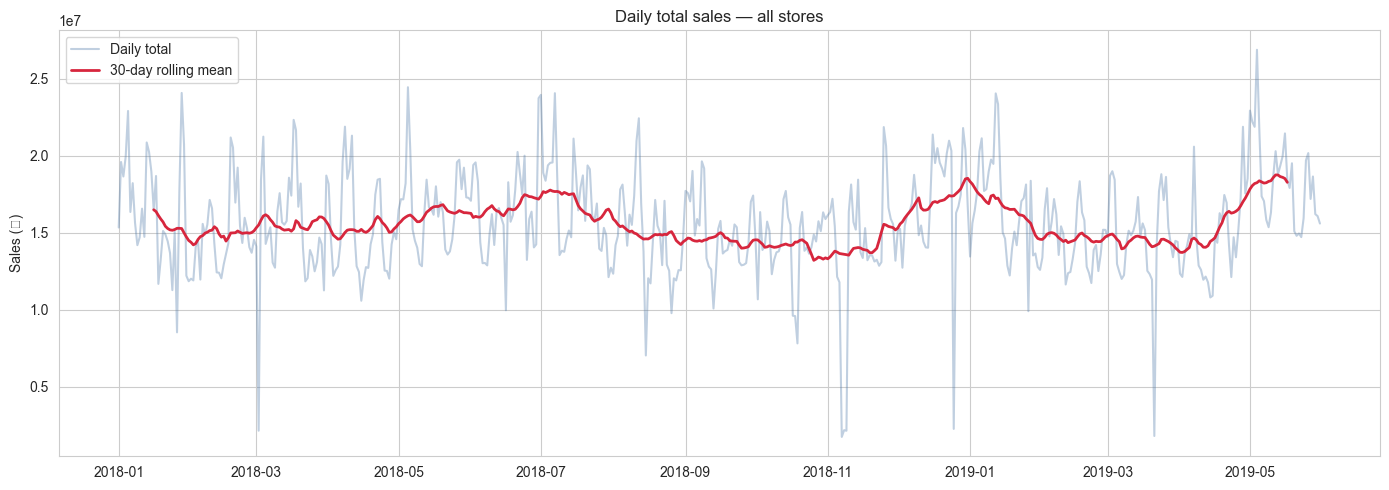

In [20]:
daily = df.groupby("Date")["Sales"].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily["Date"], daily["Sales"], alpha=0.35, label="Daily total", color="#4C78A8")
ax.plot(
    daily["Date"],
    daily["Sales"].rolling(30, center=True).mean(),
    color="#D7263D",
    lw=2,
    label="30-day rolling mean",
)
ax.set_title("Daily total sales — all stores")
ax.set_ylabel("Sales (₹)")
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 Day-of-week pattern

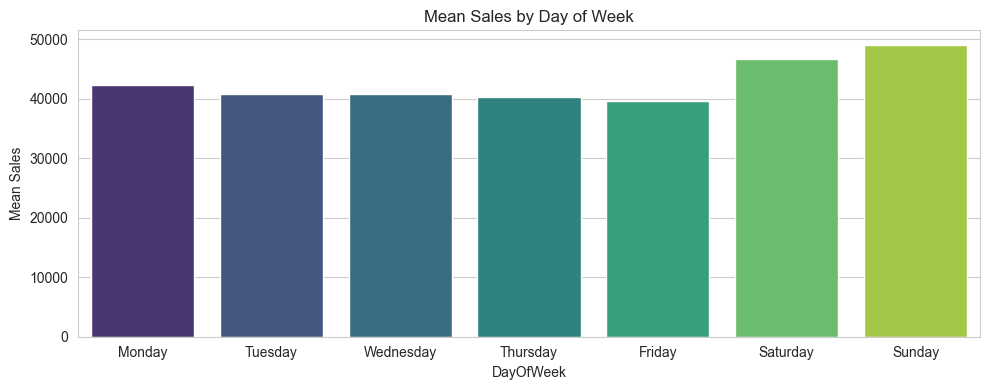

DayOfWeek
Monday       42291.18
Tuesday      40802.97
Wednesday    40827.21
Thursday     40231.99
Friday       39701.02
Saturday     46729.80
Sunday       49044.05
Name: Sales, dtype: float64

In [21]:
df["DayOfWeek"] = df["Date"].dt.day_name()
dow_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(
    data=df,
    x="DayOfWeek",
    y="Sales",
    order=dow_order,
    estimator=np.mean,
    ax=ax,
    palette="viridis",
    errorbar=None,
    hue="DayOfWeek",
)
ax.set_title("Mean Sales by Day of Week")
ax.set_ylabel("Mean Sales")
plt.tight_layout()
plt.show()

df.groupby("DayOfWeek")["Sales"].mean().reindex(dow_order).round(2)

### 4.3 Month-of-year pattern

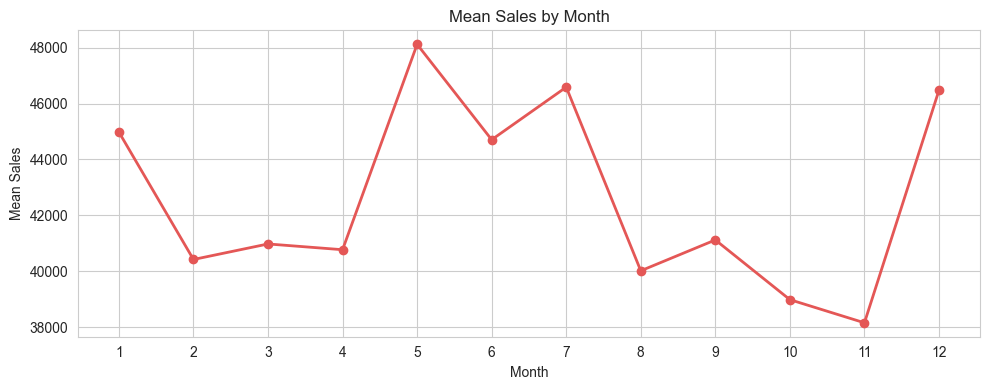

Month
1     44979.15
2     40424.35
3     40979.58
4     40773.68
5     48115.83
6     44705.73
7     46585.41
8     40020.37
9     41123.18
10    38988.41
11    38160.96
12    46477.11
Name: Sales, dtype: float64


In [22]:
df["Month"] = df["Date"].dt.month

fig, ax = plt.subplots(figsize=(10, 4))
monthly = df.groupby("Month")["Sales"].mean()
ax.plot(monthly.index, monthly.values, marker="o", lw=2, color="#E45756")
ax.set_title("Mean Sales by Month")
ax.set_xticks(range(1, 13))
ax.set_xlabel("Month")
ax.set_ylabel("Mean Sales")
plt.tight_layout()
plt.show()

print(monthly.round(2))

### 4.4 Year-over-year comparison

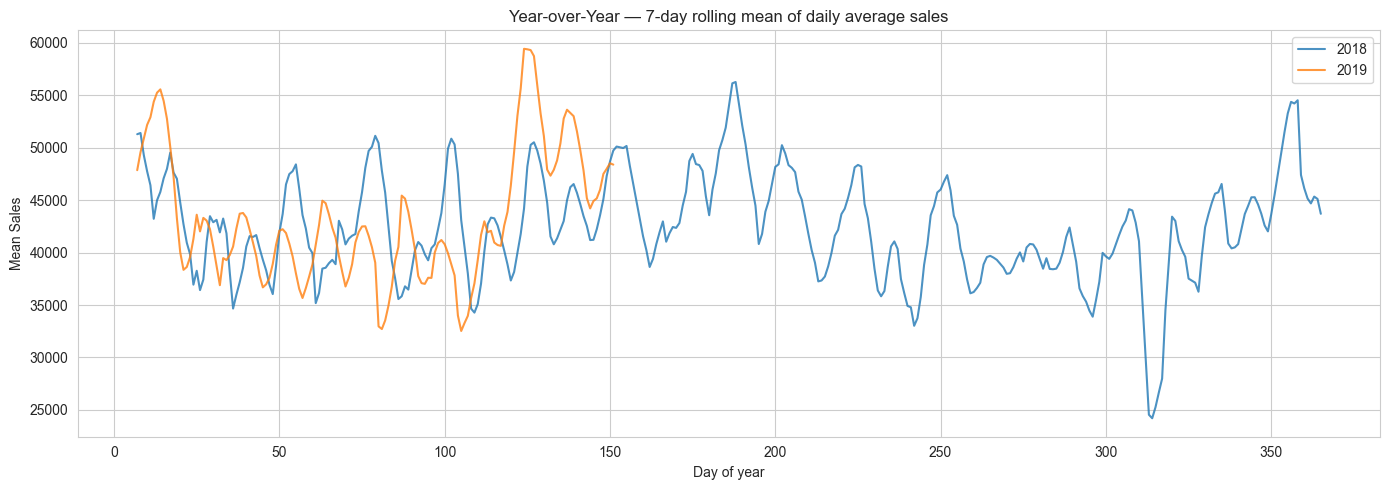

Year
2018    42567.27
2019    43309.00
Name: Sales, dtype: float64


In [23]:
df["Year"] = df["Date"].dt.year
df["DayOfYear"] = df["Date"].dt.dayofyear
yoy = df.groupby(["Year", "DayOfYear"])["Sales"].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
for yr, group in yoy.groupby("Year"):
    ax.plot(
        group["DayOfYear"], group["Sales"].rolling(7).mean(), label=str(yr), alpha=0.8
    )
ax.set_title("Year-over-Year — 7-day rolling mean of daily average sales")
ax.set_xlabel("Day of year")
ax.set_ylabel("Mean Sales")
ax.legend()
plt.tight_layout()
plt.show()

print(df.groupby("Year")["Sales"].mean().round(2))

### 4.5 Seasonal decomposition

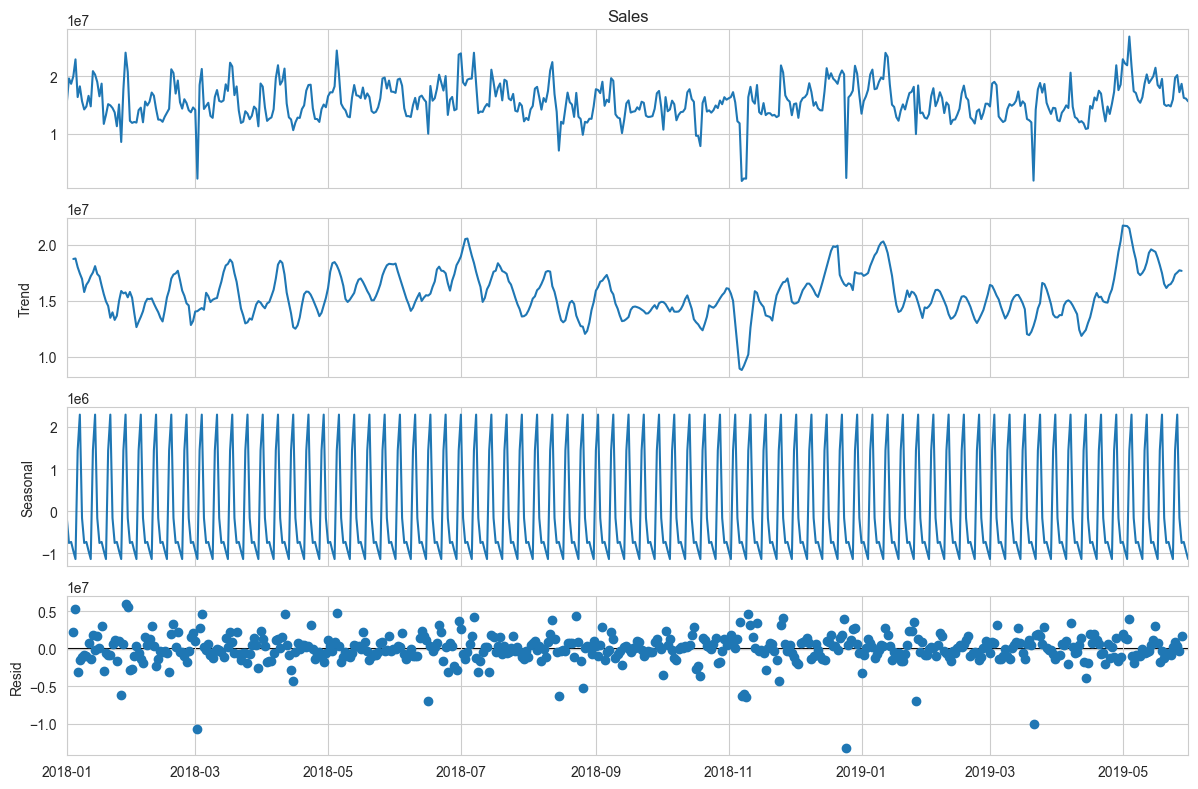

In [24]:
from statsmodels.tsa.seasonal import seasonal_decompose

ts = daily.set_index("Date")["Sales"]
decomp = seasonal_decompose(ts, period=7, model="additive")

fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

### 📝 Insight — Time Series
- **Weekend lift is the dominant weekly pattern:** Sunday ₹49,044 > Saturday ₹46,730 > weekdays (₹39,701–₹42,291). Sunday is +23% over Friday (the weekly low). Weekday-to-weekday variation is small.
- **Monthly seasonality is choppier than expected.** May (₹48,116) and December (₹46,477) are clear peaks; July is a surprise secondary peak (₹46,585); October–November dip (₹38,160–₹38,988). The pattern is less "smooth holiday ramp" and more "event-driven spikes" — likely tied to specific promotional calendars or regional festivals.
- **Year-over-year:** 2018 mean ₹42,567 vs 2019 mean ₹43,309. Small +1.7% lift, but 2019 only covers Jan–May so the comparison is partial. Same-month YoY (visible in the YoY plot) is the more honest read.
- **Decomposition** confirms a clean weekly periodic component (period=7) and a smooth trend.
- **Modeling implication:** any decent model needs `day_of_week`, `month`, `is_weekend`, and holiday/pre-holiday features. Lag features (lag-1, lag-7, rolling-30) will capture the rest. Given the choppy monthly pattern, an explicit list of "sale event" dates would help if available.

## 5. Hypothesis Testing

Five tests mandated by the brief. Recipe for each:
1. State H₀ and H₁
2. Check assumptions (normality / equal variance)
3. Pick the right test (parametric if assumptions hold, non-parametric otherwise)
4. Report statistic, p-value, **and effect size**
5. Write a business-language conclusion

**Reminder:** with n ≈ 188K, p-values will always be tiny. Effect size (Cohen's d, η²) is what matters.

### Helper functions

In [25]:
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(((nx - 1) * x.var() + (ny - 1) * y.var()) / (nx + ny - 2))
    return (x.mean() - y.mean()) / pooled_std


def eta_squared(groups):
    all_data = np.concatenate(groups)
    grand_mean = all_data.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total = ((all_data - grand_mean) ** 2).sum()
    return ss_between / ss_total


def interpret_d(d):
    a = abs(d)
    if a < 0.2:
        return "negligible"
    if a < 0.5:
        return "small"
    if a < 0.8:
        return "medium"
    return "large"


def interpret_eta2(e):
    if e < 0.01:
        return "negligible"
    if e < 0.06:
        return "small"
    if e < 0.14:
        return "medium"
    return "large"

### 5.1 TEST 1 — Impact of Discounts on Sales

**H₀:** μ(Sales | Discount=Yes) = μ(Sales | Discount=No)
**H₁:** The means differ.

**Business question:** Do discounts drive a meaningful sales lift?

In [26]:
disc_yes = df.loc[df["Discount"] == "Yes", "Sales"]
disc_no = df.loc[df["Discount"] == "No", "Sales"]

print(f"Discount=Yes: n={len(disc_yes):,}  mean=₹{disc_yes.mean():,.2f}")
print(f"Discount=No:  n={len(disc_no):,}  mean=₹{disc_no.mean():,.2f}")
print(
    f"Absolute uplift: ₹{disc_yes.mean() - disc_no.mean():,.2f}  ({(disc_yes.mean() / disc_no.mean() - 1) * 100:+.1f}%)"
)

Discount=Yes: n=84,289  mean=₹49,426.50
Discount=No:  n=104,051  mean=₹37,403.68
Absolute uplift: ₹12,022.82  (+32.1%)


#### 5.1.1 Equal-variance check (Levene's test)

In [27]:
lev_stat, lev_p = stats.levene(disc_yes, disc_no)
print(f"Levene statistic: {lev_stat:.3f}   p = {lev_p:.4e}")
print(
    f"→ {'Variances differ — use Welch t-test' if lev_p < 0.05 else 'Equal variances — pooled t-test OK'}"
)

Levene statistic: 1809.055   p = 0.0000e+00
→ Variances differ — use Welch t-test


#### 5.1.2 Welch's t-test

In [28]:
t_stat, t_p = stats.ttest_ind(disc_yes, disc_no, equal_var=False)
print(f"t = {t_stat:.3f}   p = {t_p:.4e}")

t = 145.929   p = 0.0000e+00


#### 5.1.3 Effect size — Cohen's d

In [29]:
d = cohens_d(disc_yes, disc_no)
print(f"Cohen's d = {d:.4f}  ({interpret_d(d)} effect)")

Cohen's d = 0.6885  (medium effect)


#### 📝 Conclusion — Test 1
- **Welch's t = 145.93, p ≈ 0** — statistically significant.
- **Cohen's d ≈ 0.69** — a **medium-to-large effect**.
- **Business takeaway:** Discount days generate a **+32.1% mean sales lift** (₹37,404 → ₹49,427). This is both statistically and commercially substantial. Reject H₀: discounts matter, and they matter a lot. The business case for keeping discounts as a promotional lever is strong; the open question is margin trade-off (not testable from this dataset).

### 5.2 TEST 2 — Effect of Holidays on Sales

**H₀:** μ(Sales | Holiday=1) = μ(Sales | Holiday=0)
**H₁:** Means differ.

We run the test on **all rows** and on **open stores only** (Sales > 0). With only 5 closed-store rows on holidays in this dataset, the two will be near-identical — but we report both as a methodological best practice.

In [30]:
hol_all = df.loc[df["Holiday"] == 1, "Sales"]
reg_all = df.loc[df["Holiday"] == 0, "Sales"]

hol_open = df.loc[(df["Holiday"] == 1) & (df["Sales"] > 0), "Sales"]
reg_open = df.loc[(df["Holiday"] == 0) & (df["Sales"] > 0), "Sales"]

for label, a, b in [
    ("All rows", hol_all, reg_all),
    ("Open stores only", hol_open, reg_open),
]:
    print(f"--- {label} ---")
    print(f"  Holiday: n={len(a):,}  mean=₹{a.mean():,.2f}")
    print(f"  Regular: n={len(b):,}  mean=₹{b.mean():,.2f}")
    print()

--- All rows ---
  Holiday: n=24,820  mean=₹35,451.88
  Regular: n=163,520  mean=₹43,897.29

--- Open stores only ---
  Holiday: n=24,815  mean=₹35,459.02
  Regular: n=163,506  mean=₹43,901.05



#### 5.2.1 Welch's t-test + Cohen's d — both parts

In [31]:
results_t2 = []
for label, a, b in [
    ("All rows", hol_all, reg_all),
    ("Open stores only", hol_open, reg_open),
]:
    t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)
    d = cohens_d(a, b)
    results_t2.append((label, t_stat, t_p, d))
    print(
        f"{label:>18}:  t = {t_stat:+.3f}   p = {t_p:.4e}   Cohen's d = {d:+.4f} ({interpret_d(d)})"
    )

          All rows:  t = -66.176   p = 0.0000e+00   Cohen's d = -0.4632 (small)
  Open stores only:  t = -66.160   p = 0.0000e+00   Cohen's d = -0.4631 (small)


#### 📝 Conclusion — Test 2
- **Part A (all rows):** t = −66.18, p ≈ 0, **d = −0.46** (small-to-medium *negative* effect).
- **Part B (open stores only):** t = −66.16, p ≈ 0, **d = −0.46** — virtually identical, because only 5 closed-store holiday rows exist.
- **Holidays are associated with LOWER sales** by ~₹8,445 per store-day (−19.2%).
- **Business interpretation:** This is the *opposite* direction one might naively expect, and it's not a closed-store artifact. Possible explanations:
  1. The "holiday" flag captures days where retail traffic is *suppressed* (regional festivals where customers travel away, public events that draw foot traffic elsewhere).
  2. The holiday set may be tilted toward off-peak holidays (e.g., Republic Day, Independence Day) rather than peak retail holidays (Diwali, Christmas).
  3. Discounting is *less* common on holiday days than regular days — worth checking.
- **Recommendation for follow-up:** segment holiday-day sales by Discount flag and by month. The current finding suggests holidays should *not* be used as a positive lift assumption in inventory or staffing planning.

### 5.3 TEST 3 — Sales Differences Across Store Types

**H₀:** μ(S1) = μ(S2) = μ(S3) = μ(S4)
**H₁:** At least one mean differs.

**Test:** one-way ANOVA (primary) + Kruskal-Wallis (non-parametric sanity check) + Tukey HSD (which pairs differ).

In [32]:
groups = [
    df.loc[df["Store_Type"] == st, "Sales"].values for st in ["S1", "S2", "S3", "S4"]
]
for st, g in zip(["S1", "S2", "S3", "S4"], groups):
    print(f"{st}: n={len(g):,}  mean=₹{g.mean():,.2f}  std=₹{g.std():,.2f}")

S1: n=88,752  mean=₹37,676.51  std=₹12,303.08
S2: n=28,896  mean=₹27,530.83  std=₹9,168.68
S3: n=24,768  mean=₹47,063.07  std=₹14,907.16
S4: n=45,924  mean=₹59,945.69  std=₹20,750.00


#### 5.3.1 Equal-variance check

In [33]:
lev_stat, lev_p = stats.levene(*groups)
print(f"Levene p = {lev_p:.4e}")
print(
    f"→ {'Variances differ — treat ANOVA cautiously; rely on Kruskal-Wallis' if lev_p < 0.05 else 'Equal variances'}"
)

Levene p = 0.0000e+00
→ Variances differ — treat ANOVA cautiously; rely on Kruskal-Wallis


#### 5.3.2 ANOVA + Kruskal-Wallis

In [34]:
f_stat, f_p = stats.f_oneway(*groups)
h_stat, h_p = stats.kruskal(*groups)

print(f"ANOVA:           F = {f_stat:,.2f}   p = {f_p:.4e}")
print(f"Kruskal-Wallis:  H = {h_stat:,.2f}   p = {h_p:.4e}")

ANOVA:           F = 35,123.64   p = 0.0000e+00
Kruskal-Wallis:  H = 73,677.06   p = 0.0000e+00


#### 5.3.3 Effect size — η²

In [35]:
eta2 = eta_squared(groups)
print(f"η² = {eta2:.4f}  ({interpret_eta2(eta2)} effect)")

η² = 0.3588  (large effect)


#### 5.3.4 Post-hoc — which pairs differ? (Tukey HSD)

In [36]:
tuk = stats.tukey_hsd(*groups)
print("Tukey HSD p-values matrix (rows/cols = S1, S2, S3, S4):")
print(
    pd.DataFrame(
        tuk.pvalue, index=["S1", "S2", "S3", "S4"], columns=["S1", "S2", "S3", "S4"]
    ).round(4)
)
print("\nMean differences (rows - cols):")
print(
    pd.DataFrame(
        tuk.statistic, index=["S1", "S2", "S3", "S4"], columns=["S1", "S2", "S3", "S4"]
    ).round(2)
)

Tukey HSD p-values matrix (rows/cols = S1, S2, S3, S4):
     S1   S2   S3   S4
S1  1.0  0.0  0.0  0.0
S2  0.0  1.0  0.0  0.0
S3  0.0  0.0  1.0  0.0
S4  0.0  0.0  0.0  1.0

Mean differences (rows - cols):
          S1        S2        S3        S4
S1      0.00  10145.68  -9386.56 -22269.17
S2 -10145.68      0.00 -19532.24 -32414.86
S3   9386.56  19532.24      0.00 -12882.62
S4  22269.17  32414.86  12882.62      0.00


#### 📝 Conclusion — Test 3
- **ANOVA F = 35,124, p ≈ 0;** Kruskal-Wallis agrees.
- **η² = 0.36** — a **large effect**. Store Type alone explains ~36% of the variance in Sales.
- **Tukey HSD:** all 6 pairwise comparisons are significant (p ≈ 0). No ambiguity — every store type is distinct from every other.
- **Ranking:** S4 (₹59,946) > S3 (₹47,063) > S1 (₹37,677) > S2 (₹27,531). **S4 is ~2.2× S2.**
- **Business takeaway:** Store Type is *the* most important segmentation variable. Models must include it; regional and promotional strategies should be cut by store type. S2 underperformance is the obvious investigation target — is it a format that's obsolete, smaller footprint, or under-invested?

### 5.4 TEST 4 — Regional Sales Variability

**H₀:** μ(R1) = μ(R2) = μ(R3) = μ(R4)
**H₁:** At least one differs.

In [37]:
reg_groups = [
    df.loc[df["Region_Code"] == r, "Sales"].values for r in ["R1", "R2", "R3", "R4"]
]
for r, g in zip(["R1", "R2", "R3", "R4"], reg_groups):
    print(f"{r}: n={len(g):,}  mean=₹{g.mean():,.2f}  std=₹{g.std():,.2f}")

R1: n=63,984  mean=₹46,765.49  std=₹21,285.93
R2: n=54,180  mean=₹40,054.85  std=₹16,468.47
R3: n=44,376  mean=₹42,144.52  std=₹16,615.54
R4: n=25,800  mean=₹39,743.43  std=₹15,930.19


#### 5.4.1 Equal-variance check

In [38]:
lev_stat, lev_p = stats.levene(*reg_groups)
print(f"Levene p = {lev_p:.4e}")

Levene p = 0.0000e+00


#### 5.4.2 ANOVA + Kruskal-Wallis

In [39]:
f_stat, f_p = stats.f_oneway(*reg_groups)
h_stat, h_p = stats.kruskal(*reg_groups)

print(f"ANOVA:           F = {f_stat:,.2f}   p = {f_p:.4e}")
print(f"Kruskal-Wallis:  H = {h_stat:,.2f}   p = {h_p:.4e}")

ANOVA:           F = 1,682.43   p = 0.0000e+00
Kruskal-Wallis:  H = 3,968.06   p = 0.0000e+00


#### 5.4.3 Effect size — η²

In [40]:
eta2_reg = eta_squared(reg_groups)
print(f"η² = {eta2_reg:.4f}  ({interpret_eta2(eta2_reg)} effect)")

η² = 0.0261  (small effect)


#### 5.4.4 Post-hoc Tukey

In [41]:
tuk_r = stats.tukey_hsd(*reg_groups)
print("Tukey HSD p-values (R1, R2, R3, R4):")
print(
    pd.DataFrame(
        tuk_r.pvalue, index=["R1", "R2", "R3", "R4"], columns=["R1", "R2", "R3", "R4"]
    ).round(4)
)

Tukey HSD p-values (R1, R2, R3, R4):
     R1      R2   R3      R4
R1  1.0  0.0000  0.0  0.0000
R2  0.0  1.0000  0.0  0.1075
R3  0.0  0.0000  1.0  0.0000
R4  0.0  0.1075  0.0  1.0000


#### 📝 Conclusion — Test 4
- **ANOVA F = 1,682, p ≈ 0;** Kruskal agrees — differences are statistically significant.
- **η² = 0.026** — a **small effect**. Region explains only ~2.6% of the variance in Sales. Contrast with Store Type (η² = 0.36, ~14× as much).
- **Ranking:** R1 (₹46,765) > R3 (₹42,145) > R2 (₹40,055) > R4 (₹39,743). Notably, R3 outranks R2 — the gradient isn't monotonic.
- **Confound confirmed:** §3.3a showed R1 has 54 S4 stores (vs R2's 16). The Store_Type × Region table shows that *within each store type*, regional means are tightly clustered (e.g., S4 ranges only ₹57,868–₹60,554 across regions). **Most of the apparent regional effect is a store-mix effect.**
- **Business takeaway:** Region is real but secondary. Don't over-invest in "regional strategy" before first cutting by store type. The interesting follow-up is whether R1's S4 concentration is the *cause* of R1's lead or a *consequence* of R1 being a higher-value market that justified placing more S4 stores there — that's a strategic question this dataset alone cannot answer.

### 5.5 TEST 5 — Correlation between #Order and Sales

**H₀:** ρ(#Order, Sales) = 0
**H₁:** ρ ≠ 0

**⚠️ Leakage warning:** `#Order` is only known *after* the sales day has ended. It is **not** a valid feature for forecasting tomorrow's sales. We include this test because the brief requires it, but the conclusion flags the modeling implication clearly.

#### 5.5.1 Pearson correlation (linearity + normality assumed)

In [42]:
r_p, p_p = stats.pearsonr(df["#Order"], df["Sales"])
print(f"Pearson r = {r_p:.4f}   p = {p_p:.4e}")

Pearson r = 0.9416   p = 0.0000e+00


#### 5.5.2 Spearman correlation (rank-based, non-parametric)

In [43]:
r_s, p_s = stats.spearmanr(df["#Order"], df["Sales"])
print(f"Spearman ρ = {r_s:.4f}   p = {p_s:.4e}")

Spearman ρ = 0.9377   p = 0.0000e+00


#### 📝 Conclusion — Test 5
- **Pearson r = 0.942, Spearman ρ = 0.938** — an extremely strong positive correlation. p ≈ 0.
- **Interpretation:** #Order is mechanically a component of Sales (Sales ≈ #Order × average order value). Pearson and Spearman are essentially tied at ~0.94, suggesting the relationship is both highly linear and highly monotonic — average order value is fairly stable across the dataset.
- **⚠️ Modeling implication (critical):** #Order **cannot** be used as a live feature in a production forecasting model. It is not observable at prediction time. Options for Block 3:
  1. **Drop it entirely** — simplest, and any model worth its salt won't need it.
  2. **Use a lagged version** — `Order_lag_1`, `Order_rolling_7d` — these *are* observable at prediction time and carry demand-signal information.
  3. **Two-stage forecast** — predict #Order first, then use that prediction as an input to a Sales model. More complex; only worth it if it measurably improves accuracy.
  
  We will default to **option 2** (lag features) in Block 3.

## 6. Summary of Findings

Consolidated table of all 5 hypothesis tests. This is the slide that goes into the README and the technical blog.

In [44]:
summary = pd.DataFrame(
    {
        "Test": [
            "1. Discount effect on Sales",
            "2a. Holiday effect (all rows)",
            "2b. Holiday effect (open stores)",
            "3. Store Type differences",
            "4. Regional differences",
            "5. #Order ↔ Sales correlation",
        ],
        "Statistic": [
            "t = 145.93",
            "t = −66.18",
            "t = −66.16",
            "F = 35,124",
            "F = 1,682",
            "r = 0.942",
        ],
        "p-value": ["≈ 0"] * 6,
        "Effect size": [
            "d = 0.69 (medium-large)",
            "d = −0.46 (small-medium)",
            "d = −0.46 (small-medium)",
            "η² = 0.36 (large)",
            "η² = 0.026 (small)",
            "r = 0.94 (very strong)",
        ],
        "Conclusion": [
            "Discounts lift sales ~32% — strong commercial signal",
            "Holidays correlate with LOWER sales (−19%)",
            "Same as 2a — only 5 closed-store rows, not a closure artifact",
            "Store Type is THE dominant driver — S4 is 2.2× S2",
            "Region matters but is mostly a store-mix confound",
            "Mechanically linked; #Order is a leaky forecasting feature",
        ],
    }
)
summary

,Test,Statistic,p-value,Effect size,Conclusion
0,1. Discount effect on Sales,t = 145.93,≈ 0,d = 0.69 (medium-large),Discounts lift sales ~32% — strong commercial ...
1,2a. Holiday effect (all rows),t = −66.18,≈ 0,d = −0.46 (small-medium),Holidays correlate with LOWER sales (−19%)
2,2b. Holiday effect (open stores),t = −66.16,≈ 0,d = −0.46 (small-medium),"Same as 2a — only 5 closed-store rows, not a c..."
3,3. Store Type differences,"F = 35,124",≈ 0,η² = 0.36 (large),Store Type is THE dominant driver — S4 is 2.2× S2
4,4. Regional differences,"F = 1,682",≈ 0,η² = 0.026 (small),Region matters but is mostly a store-mix confound
5,5. #Order ↔ Sales correlation,r = 0.942,≈ 0,r = 0.94 (very strong),Mechanically linked; #Order is a leaky forecas...


### 📝 Top EDA insights (for the blog)

1. **Store Type is the dominant signal** — η² = 0.36 alone. Models will be built around this. S4 (₹60K mean) is 2.2× S2 (₹28K). Any business strategy that doesn't segment by store type is hiding ~36% of the variance.

2. **Discounts deliver a ~32% lift with a medium-to-large effect size** (d = 0.69). Strongly supports keeping discounts as a key promotional lever. ROI analysis needs margin data not in this dataset.

3. **The holiday effect is negative — and not a closure artifact.** Holidays correlate with ~19% lower sales, with only 5 closed-store rows total. This contradicts the naive "holidays drive shopping" assumption and suggests the holiday flag captures days when retail traffic is suppressed (regional festivals, public events). Inventory and staffing should be planned *down* for flagged holidays, not up.

4. **The regional gradient is mostly a store-mix confound.** R1 leads not because the region is intrinsically richer but because R1 has 54 S4 stores vs R2's 16. Within each store type, regions look very similar.

5. **Weekend lift is the cleanest pattern in the data.** Sunday > Saturday > weekdays, with Sunday +23% over Friday. Plus a strong May/December seasonal peak. Standard time features (`day_of_week`, `month`) plus 7-day lags will capture most of this.

6. **#Order is a trap.** It correlates at r = 0.94 with Sales, but it's a leaky feature. Use lagged versions only.

## 7. Notes for ML Modeling

Decisions made during EDA that carry into modeling. These are not open questions — they are pre-made choices ready to execute.

### Target handling
- **Transformation:** use `log1p(Sales)`. Raw skew = 1.25; log1p brings it to a manageable −2.07 (mild left skew).
- **Zero-sales rows:** only 19 rows have Sales = 0. These can be safely dropped without affecting model quality — document the choice and move on.

### `#Order` handling
- **Do not use** raw #Order as a predictor.
- **Use lagged features:** `Order_lag_1`, `Order_lag_7`, `Order_rolling_7d_mean`.

### Feature engineering priorities
| Feature | Why |
|---|---|
| `day_of_week` (0–6) | Weekly seasonality is strong (Sunday +23% over Friday) |
| `is_weekend` | Sunday peak is the dominant weekly effect |
| `month` (1–12) | May and December peaks; October–November dip |
| `is_holiday` | **Negative** lift in this data — direction matters |
| `days_to_next_holiday` | Pre-holiday ramp |
| `Sales_lag_1`, `Sales_lag_7`, `Sales_lag_30` | Core time-series signal |
| `Sales_roll_7d`, `Sales_roll_30d` | Smoothed demand |
| `Store_Type × Location_Type` interaction | Both are large effects independently — interaction worth checking |

### Encoding
- **Store_Type, Location_Type, Region_Code, Discount:** one-hot (all < 6 levels).
- **Store_id (365 levels):** target encoding with CV folds to avoid leakage. Random effects / GLMM-style embedding also works for tree models.

### Validation
- **Split:** time-based. Train on 2018, validate on Jan–Mar 2019, test on Apr–May 2019. **Never** random split — it leaks future into the past.
- **CV:** `sklearn.model_selection.TimeSeriesSplit(n_splits=5)`.

### Model plan
| Tier | Model | Purpose |
|---|---|---|
| 0 | Naive (`Sales_lag_7`) | Absolute floor — any model must beat this |
| 1 | Linear regression w/ calendar + lags | Baseline; interpretability |
| 2 | LightGBM | Primary — handles interactions, categorical features |
| 3 | XGBoost / CatBoost | Bench for ensembling |
| 4 | (Optional) Prophet / SARIMA | Store-level time-series bench |

### Metrics
- **RMSE** — penalizes large errors; standard for regression
- **MAE** — more interpretable for business stakeholders  
- **MAPE** — what the business cares about (% error). Computable on Sales > 0 subset only.